# Supervised Learning for Fraud Detection

This notebook implements and compares multiple supervised learning models for fraud detection:
- **Logistic Regression** (baseline linear model)
- **Random Forest** (ensemble tree-based model)
- **XGBoost** (gradient boosting model)

## Experimental Design:

We will train each model under different data balancing strategies:
1. **No SMOTE** (baseline - imbalanced data)
2. **Standard SMOTE**
3. **Borderline-SMOTE**
4. **ADASYN**
5. **SMOTE-Tomek**

**Evaluation Strategy**:
- Train all model × SMOTE combinations on training set
- Evaluate on validation set to select best combination
- Final evaluation on test set (only once, with best model)
- Metrics: Precision, Recall, F1-Score, AUC-ROC, AUC-PR (Precision-Recall)

**Why this approach is fair**:
- All models see all SMOTE variants
- Validation set used for selection (not test set)
- Can compare if SMOTE helps vs. baseline
- Identifies which SMOTE works best for which model

## 1. Import Required Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# SMOTE variants
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    precision_recall_curve, roc_curve, auc,
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score
)

# Set random seed
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load Datasets

Load the train, validation, and test sets prepared from the SMOTE notebook.

In [8]:
# Download and load dataset from Kaggle
import kagglehub
import os
import shutil

# Create the data/raw directory if it doesn't exist
os.makedirs("../data/raw", exist_ok=True)

path = kagglehub.dataset_download("sriharshaeedala/financial-fraud-detection-dataset")
print("Dataset downloaded to:", path)

target_dir = "../data/raw/financial-fraud-detection-dataset"
if os.path.exists(target_dir):
    shutil.rmtree(target_dir)
shutil.copytree(path, target_dir)
print(f"Dataset copied to: {target_dir}")

# Load the dataset
csv_file = os.path.join(target_dir, "Synthetic_Financial_datasets_log.csv")
print(f"Loading file: {csv_file}")

df = pd.read_csv(csv_file)
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

Dataset downloaded to: /Users/angjiayi/.cache/kagglehub/datasets/sriharshaeedala/financial-fraud-detection-dataset/versions/1
Dataset copied to: ../data/raw/financial-fraud-detection-dataset
Loading file: ../data/raw/financial-fraud-detection-dataset/Synthetic_Financial_datasets_log.csv
Dataset copied to: ../data/raw/financial-fraud-detection-dataset
Loading file: ../data/raw/financial-fraud-detection-dataset/Synthetic_Financial_datasets_log.csv

Dataset shape: (6362620, 11)

First few rows:
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFr

## 3. Feature Engineering

Recreate the key features identified in the EDA phase.

In [9]:
# Create day feature
df['day'] = df['step'] // 24

# Network features
df['distinctNameDest_perSender'] = df.groupby('nameOrig')['nameDest'].transform('nunique')
df['distinctNameOrig_perReceiver'] = df.groupby('nameDest')['nameOrig'].transform('nunique')

# Average amount to destination
df['avgAmountToDest'] = df.groupby(['nameOrig', 'nameDest'])['amount'].transform('mean')

# Number of repeat transactions
df['numRepeatTxnsWithDest'] = df.groupby(['nameOrig', 'nameDest'])['amount'].transform('count')

# Time since last transaction
df = df.sort_values(['nameOrig', 'step']).reset_index(drop=True)
df['timeSinceLastTransaction'] = df.groupby('nameOrig')['step'].diff().fillna(999)

# Same user transaction flag
df['sameUserTransaction'] = (df['nameOrig'] == df['nameDest']).astype(int)

# Sender aggregations
sender_agg = df.groupby('nameOrig').agg(
    totalSent=('amount', 'sum'),
    meanSent=('amount', 'mean'),
    stdSent=('amount', 'std'),
    numSent=('amount', 'count')
).reset_index()
df = df.merge(sender_agg, on='nameOrig', how='left')

# Receiver aggregations
receiver_agg = df.groupby('nameDest').agg(
    totalReceived=('amount', 'sum'),
    meanReceived=('amount', 'mean'),
    stdReceived=('amount', 'std'),
    numReceived=('amount', 'count')
).reset_index()
df = df.merge(receiver_agg, on='nameDest', how='left')

# Transaction type fractions for senders
type_sender = df.groupby(['nameOrig', 'type']).size().unstack(fill_value=0)
type_sender = type_sender.div(type_sender.sum(axis=1), axis=0)
type_sender.columns = [f'fraction_{col}' for col in type_sender.columns]
df = df.merge(type_sender, left_on='nameOrig', right_index=True, how='left')

# Transaction type fractions for receivers
type_receiver = df.groupby(['nameDest', 'type']).size().unstack(fill_value=0)
type_receiver = type_receiver.div(type_receiver.sum(axis=1), axis=0)
type_receiver.columns = [f'fraction_{col}_recv' for col in type_receiver.columns]
df = df.merge(type_receiver, left_on='nameDest', right_index=True, how='left')

# Fraud ratios
fraud_by_receiver = df.groupby('nameDest')['isFraud'].mean().reset_index()
fraud_by_receiver.columns = ['nameDest', 'fraudRatioAmongReceivers']
df = df.merge(fraud_by_receiver, on='nameDest', how='left')

fraud_by_sender = df.groupby('nameOrig')['isFraud'].mean().reset_index()
fraud_by_sender.columns = ['nameOrig', 'fraudRatioAmongSenders']
df = df.merge(fraud_by_sender, on='nameOrig', how='left')

# Balance annihilation
df['isBalanceAnnihilation'] = ((df['oldbalanceOrg'] > 0) & (df['newbalanceOrig'] == 0)).astype(int)

print(f"\nFeature engineering complete. Dataset shape: {df.shape}")


Feature engineering complete. Dataset shape: (6362620, 39)


## 4. Prepare Features and Split Data

Select relevant features, encode categoricals, and split into train/validation/test sets.

In [10]:
# Encode transaction type
df['type_encoded'] = df['type'].astype('category').cat.codes

# Select features for modeling
feature_columns = [
    'step', 'type_encoded', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest', 'day',
    'distinctNameDest_perSender', 'distinctNameOrig_perReceiver',
    'avgAmountToDest', 'numRepeatTxnsWithDest', 'timeSinceLastTransaction',
    'sameUserTransaction', 'totalSent', 'meanSent', 'stdSent', 'numSent',
    'totalReceived', 'meanReceived', 'stdReceived', 'numReceived',
    'fraudRatioAmongReceivers', 'fraudRatioAmongSenders', 'isBalanceAnnihilation'
]

# Add fraction columns (they may have different types)
fraction_cols = [col for col in df.columns if col.startswith('fraction_')]
feature_columns.extend(fraction_cols)

# Prepare X and y
X = df[feature_columns].copy()
y = df['isFraud'].copy()

# Handle missing values
X = X.fillna(0)

print(f"Features selected: {len(feature_columns)}")
print(f"Feature list: {feature_columns[:10]}... ({len(feature_columns)} total)")
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nClass distribution:")
print(f"  Non-fraud: {(y==0).sum():,} ({(y==0).sum()/len(y)*100:.4f}%)")
print(f"  Fraud: {(y==1).sum():,} ({(y==1).sum()/len(y)*100:.4f}%)")

Features selected: 35
Feature list: ['step', 'type_encoded', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'day', 'distinctNameDest_perSender', 'distinctNameOrig_perReceiver']... (35 total)

X shape: (6362620, 35)
y shape: (6362620,)

Class distribution:
  Non-fraud: 6,354,407 (99.8709%)
  Fraud: 8,213 (0.1291%)


In [11]:
# Split data: Train (64%), Validation (16%), Test (20%)
from sklearn.model_selection import train_test_split

# First split: separate out test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: split remaining into train (80%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

print(f"Training set size: {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set size: {X_val.shape[0]:,} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nTraining set class distribution:")
print(f"  Non-fraud: {(y_train==0).sum():,} ({(y_train==0).sum()/len(y_train)*100:.4f}%)")
print(f"  Fraud: {(y_train==1).sum():,} ({(y_train==1).sum()/len(y_train)*100:.4f}%)")

print(f"\nValidation set class distribution:")
print(f"  Non-fraud: {(y_val==0).sum():,} ({(y_val==0).sum()/len(y_val)*100:.4f}%)")
print(f"  Fraud: {(y_val==1).sum():,} ({(y_val==1).sum()/len(y_val)*100:.4f}%)")

print(f"\nTest set class distribution:")
print(f"  Non-fraud: {(y_test==0).sum():,} ({(y_test==0).sum()/len(y_test)*100:.4f}%)")
print(f"  Fraud: {(y_test==1).sum():,} ({(y_test==1).sum()/len(y_test)*100:.4f}%)")

Training set size: 4,072,076 (64.0%)
Validation set size: 1,018,020 (16.0%)
Test set size: 1,272,524 (20.0%)

Training set class distribution:
  Non-fraud: 4,066,820 (99.8709%)
  Fraud: 5,256 (0.1291%)

Validation set class distribution:
  Non-fraud: 1,016,706 (99.8709%)
  Fraud: 1,314 (0.1291%)

Test set class distribution:
  Non-fraud: 1,270,881 (99.8709%)
  Fraud: 1,643 (0.1291%)


## 5. Define SMOTE Strategies and Models

Set up all SMOTE variants and model configurations we want to compare.

In [12]:
# Define SMOTE strategies
smote_strategies = {
    'No SMOTE': None,
    'Standard SMOTE': SMOTE(random_state=42, k_neighbors=5),
    'Borderline-SMOTE': BorderlineSMOTE(random_state=42, k_neighbors=5),
    'ADASYN': ADASYN(random_state=42, n_neighbors=5),
    # Note: SMOTE-Tomek removed - too slow for large datasets (6M+ transactions)
    # Alternative: Use standard SMOTE and tune model hyperparameters instead
}

# Define models
models = {
    'Logistic Regression': LogisticRegression(
        random_state=42, 
        max_iter=1000,
        class_weight='balanced'  # Handle imbalance for baseline
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=10,
        class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train)  # Handle imbalance
    )
}

print(f"SMOTE strategies: {len(smote_strategies)}")
print(f"Models: {len(models)}")
print(f"Total combinations to train: {len(smote_strategies) * len(models)}")

SMOTE strategies: 4
Models: 3
Total combinations to train: 12


## 6. Training Pipeline

Train all model × SMOTE combinations and evaluate on validation set.

In [13]:
# Store results
results = []
trained_models = {}

# Train all combinations
for smote_name, smote in smote_strategies.items():
    print(f"\n{'='*80}")
    print(f"SMOTE Strategy: {smote_name}")
    print(f"{'='*80}")
    
    # Apply SMOTE if not None
    if smote is not None:
        print(f"Applying {smote_name}...")
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
        print(f"Training set size after {smote_name}: {len(X_train_resampled):,}")
        print(f"Fraud ratio: {y_train_resampled.mean()*100:.2f}%")
    else:
        X_train_resampled = X_train
        y_train_resampled = y_train
        print(f"Using original imbalanced training set: {len(X_train_resampled):,}")
        print(f"Fraud ratio: {y_train_resampled.mean()*100:.4f}%")
    
    # Train each model
    for model_name, model in models.items():
        print(f"\n  Training {model_name}...")
        
        # Clone model to avoid contamination
        from sklearn.base import clone
        model_clone = clone(model)
        
        # Train
        model_clone.fit(X_train_resampled, y_train_resampled)
        
        # Predict on validation set
        y_val_pred = model_clone.predict(X_val)
        y_val_pred_proba = model_clone.predict_proba(X_val)[:, 1]
        
        # Calculate metrics
        precision = precision_score(y_val, y_val_pred)
        recall = recall_score(y_val, y_val_pred)
        f1 = f1_score(y_val, y_val_pred)
        roc_auc = roc_auc_score(y_val, y_val_pred_proba)
        pr_auc = average_precision_score(y_val, y_val_pred_proba)
        
        # Store results
        result = {
            'SMOTE': smote_name,
            'Model': model_name,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'ROC-AUC': roc_auc,
            'PR-AUC': pr_auc
        }
        results.append(result)
        
        # Store trained model
        trained_models[f"{smote_name}_{model_name}"] = model_clone
        
        print(f"    Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}")

print(f"\n{'='*80}")
print("Training complete!")
print(f"{'='*80}")


SMOTE Strategy: No SMOTE
Using original imbalanced training set: 4,072,076
Fraud ratio: 0.1291%

  Training Logistic Regression...
    Precision: 0.0287 | Recall: 0.8836 | F1: 0.0555 | ROC-AUC: 0.9805 | PR-AUC: 0.5190

  Training Random Forest...
    Precision: 0.0287 | Recall: 0.8836 | F1: 0.0555 | ROC-AUC: 0.9805 | PR-AUC: 0.5190

  Training Random Forest...
    Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000 | ROC-AUC: 1.0000 | PR-AUC: 1.0000

  Training XGBoost...
    Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000 | ROC-AUC: 1.0000 | PR-AUC: 1.0000

  Training XGBoost...
    Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000 | ROC-AUC: 1.0000 | PR-AUC: 1.0000

SMOTE Strategy: Standard SMOTE
Applying Standard SMOTE...
    Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000 | ROC-AUC: 1.0000 | PR-AUC: 1.0000

SMOTE Strategy: Standard SMOTE
Applying Standard SMOTE...
Training set size after Standard SMOTE: 8,133,640
Fraud ratio: 50.00%

  Training Logistic Regression...
Training set size a

## 7. Results Comparison

Compare all model × SMOTE combinations on validation set.

In [14]:
# Create results dataframe
results_df = pd.DataFrame(results)

# Sort by F1-Score (can change to other metric)
results_df = results_df.sort_values('F1-Score', ascending=False)

print("\n" + "="*100)
print("VALIDATION SET RESULTS - ALL COMBINATIONS")
print("="*100)
print(results_df.to_string(index=False))

# Find best combination
best_idx = results_df['F1-Score'].idxmax()
best_result = results_df.loc[best_idx]

print("\n" + "="*100)
print("BEST COMBINATION (by F1-Score on validation set):")
print("="*100)
print(f"SMOTE: {best_result['SMOTE']}")
print(f"Model: {best_result['Model']}")
print(f"Precision: {best_result['Precision']:.4f}")
print(f"Recall: {best_result['Recall']:.4f}")
print(f"F1-Score: {best_result['F1-Score']:.4f}")
print(f"ROC-AUC: {best_result['ROC-AUC']:.4f}")
print(f"PR-AUC: {best_result['PR-AUC']:.4f}")


VALIDATION SET RESULTS - ALL COMBINATIONS
           SMOTE               Model  Precision   Recall  F1-Score  ROC-AUC   PR-AUC
        No SMOTE       Random Forest   1.000000 1.000000  1.000000 1.000000 1.000000
        No SMOTE             XGBoost   1.000000 1.000000  1.000000 1.000000 1.000000
  Standard SMOTE       Random Forest   1.000000 1.000000  1.000000 1.000000 1.000000
          ADASYN       Random Forest   1.000000 1.000000  1.000000 1.000000 1.000000
Borderline-SMOTE       Random Forest   1.000000 0.999239  0.999619 1.000000 1.000000
  Standard SMOTE             XGBoost   0.999239 0.999239  0.999239 1.000000 0.999999
Borderline-SMOTE             XGBoost   0.999239 0.999239  0.999239 1.000000 0.999998
          ADASYN             XGBoost   0.999239 0.999239  0.999239 1.000000 0.999999
Borderline-SMOTE Logistic Regression   0.033749 0.917808  0.065105 0.979763 0.606889
        No SMOTE Logistic Regression   0.028655 0.883562  0.055510 0.980456 0.519021
  Standard SMOTE Logis

## 8. Visualize Results

Create comparison visualizations across all combinations.

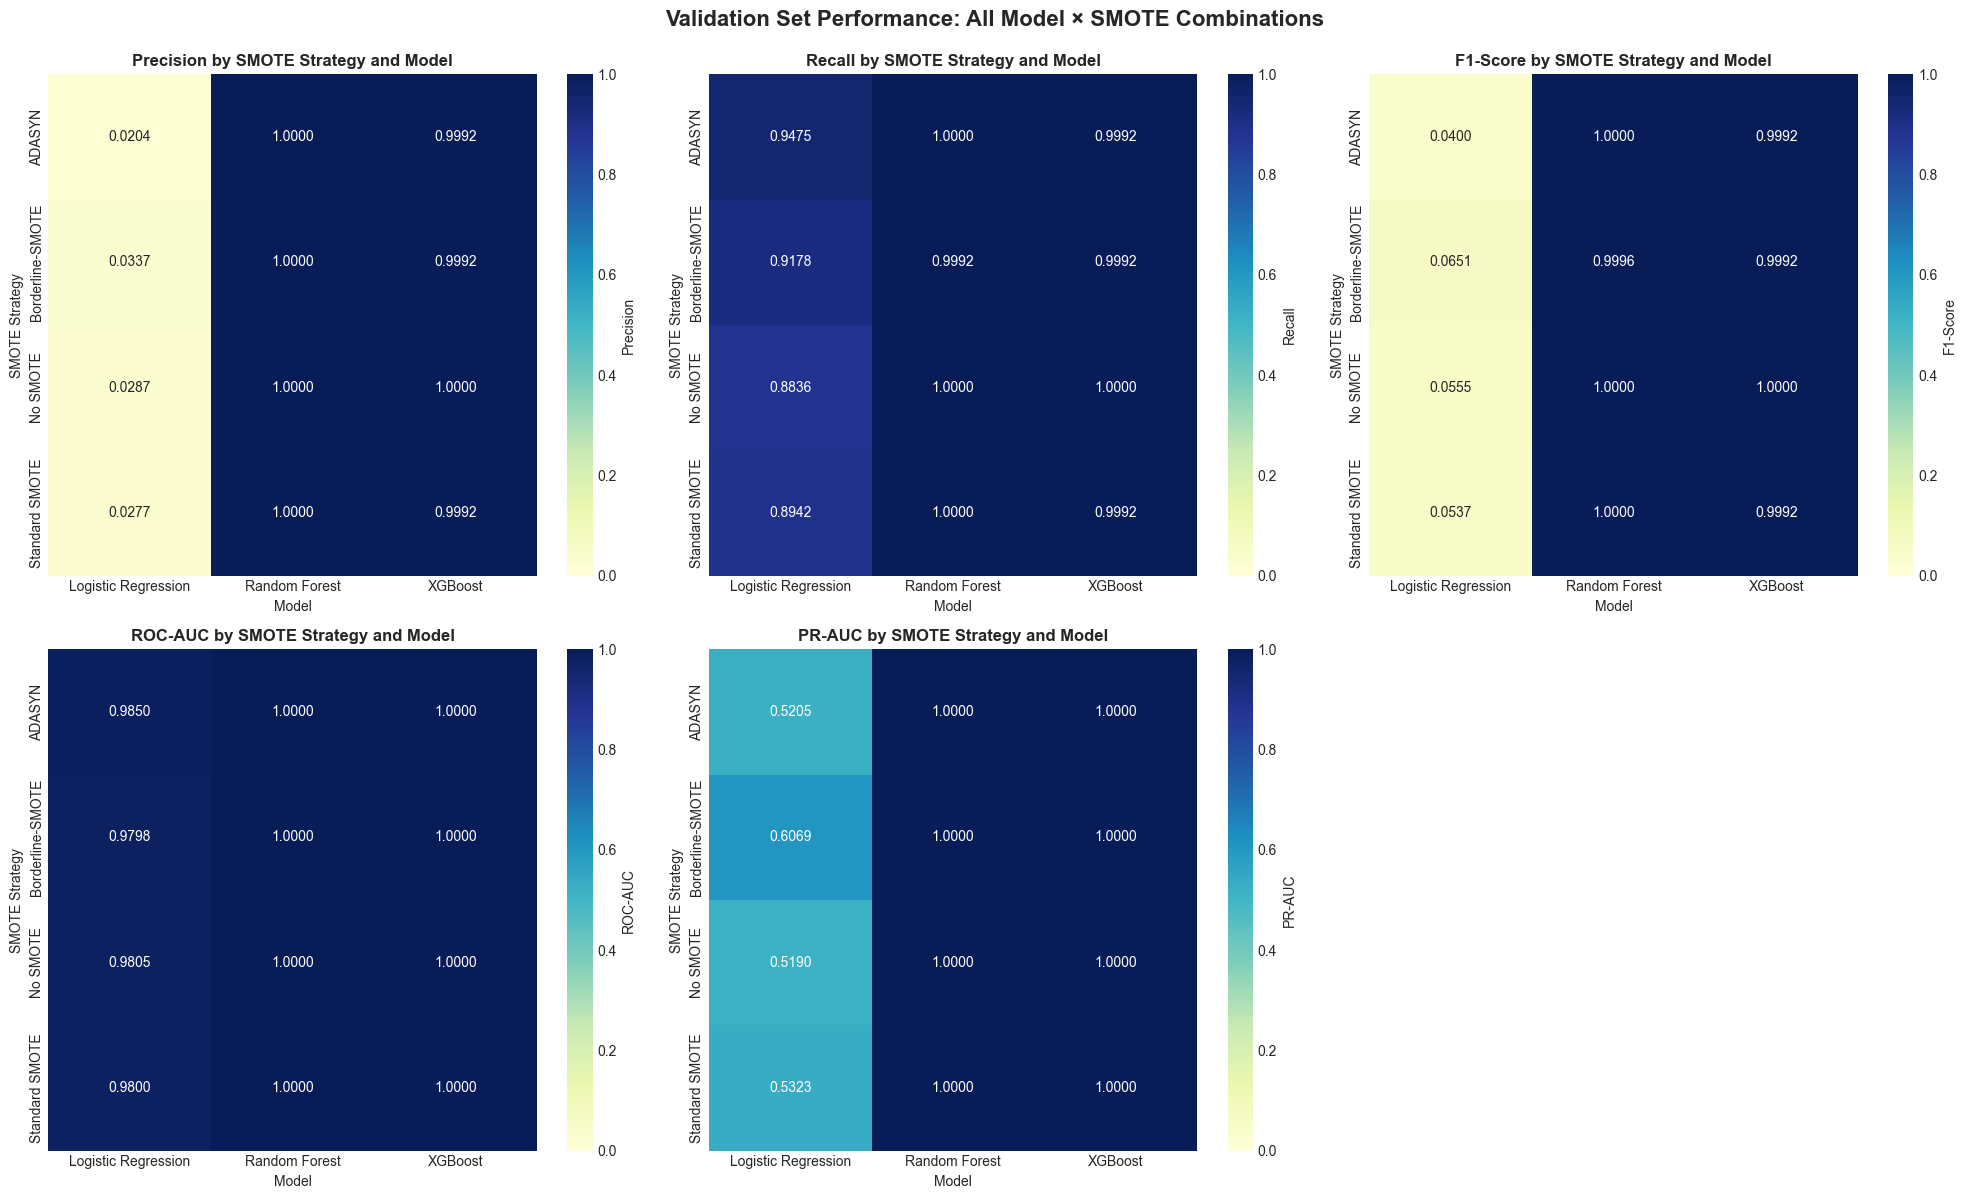

In [15]:
# Create pivot tables for heatmaps
metrics = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    pivot = results_df.pivot(index='SMOTE', columns='Model', values=metric)
    
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', ax=axes[idx], 
                cbar_kws={'label': metric}, vmin=0, vmax=1)
    axes[idx].set_title(f'{metric} by SMOTE Strategy and Model', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Model', fontsize=10)
    axes[idx].set_ylabel('SMOTE Strategy', fontsize=10)

# Remove extra subplot
fig.delaxes(axes[5])

plt.suptitle('Validation Set Performance: All Model × SMOTE Combinations', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

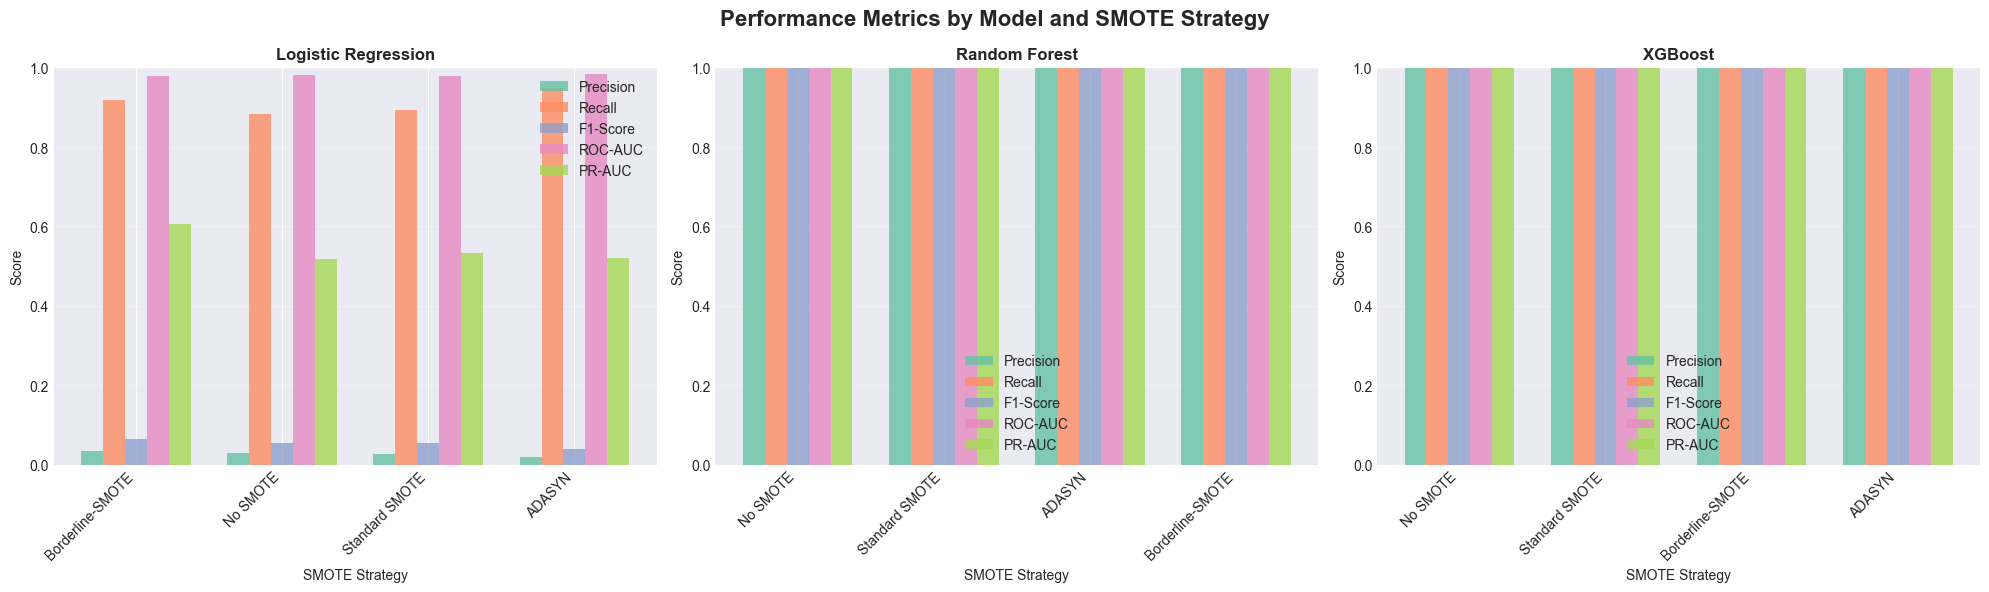

In [16]:
# Bar plot comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, model_name in enumerate(models.keys()):
    model_results = results_df[results_df['Model'] == model_name]
    
    x = np.arange(len(model_results))
    width = 0.15
    
    axes[idx].bar(x - 2*width, model_results['Precision'], width, label='Precision', alpha=0.8)
    axes[idx].bar(x - width, model_results['Recall'], width, label='Recall', alpha=0.8)
    axes[idx].bar(x, model_results['F1-Score'], width, label='F1-Score', alpha=0.8)
    axes[idx].bar(x + width, model_results['ROC-AUC'], width, label='ROC-AUC', alpha=0.8)
    axes[idx].bar(x + 2*width, model_results['PR-AUC'], width, label='PR-AUC', alpha=0.8)
    
    axes[idx].set_xlabel('SMOTE Strategy', fontsize=10)
    axes[idx].set_ylabel('Score', fontsize=10)
    axes[idx].set_title(f'{model_name}', fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(model_results['SMOTE'], rotation=45, ha='right')
    axes[idx].legend()
    axes[idx].set_ylim(0, 1)
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Performance Metrics by Model and SMOTE Strategy', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Detailed Analysis of Best Model

Examine the best performing model in detail.

In [17]:
# Get best model
best_model_key = f"{best_result['SMOTE']}_{best_result['Model']}"
best_model = trained_models[best_model_key]

# Predictions on validation set
y_val_pred = best_model.predict(X_val)
y_val_pred_proba = best_model.predict_proba(X_val)[:, 1]

print("\n" + "="*80)
print(f"DETAILED ANALYSIS: {best_result['Model']} with {best_result['SMOTE']}")
print("="*80)

# Classification report
print("\nClassification Report (Validation Set):")
print(classification_report(y_val, y_val_pred, target_names=['Non-Fraud', 'Fraud']))

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
print("\nConfusion Matrix:")
print(cm)
print(f"\nTrue Negatives: {cm[0,0]:,}")
print(f"False Positives: {cm[0,1]:,}")
print(f"False Negatives: {cm[1,0]:,}")
print(f"True Positives: {cm[1,1]:,}")


DETAILED ANALYSIS: Random Forest with No SMOTE

Classification Report (Validation Set):
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00   1016706
       Fraud       1.00      1.00      1.00      1314

    accuracy                           1.00   1018020
   macro avg       1.00      1.00      1.00   1018020
weighted avg       1.00      1.00      1.00   1018020


Confusion Matrix:
[[1016706       0]
 [      0    1314]]

True Negatives: 1,016,706
False Positives: 0
False Negatives: 0
True Positives: 1,314


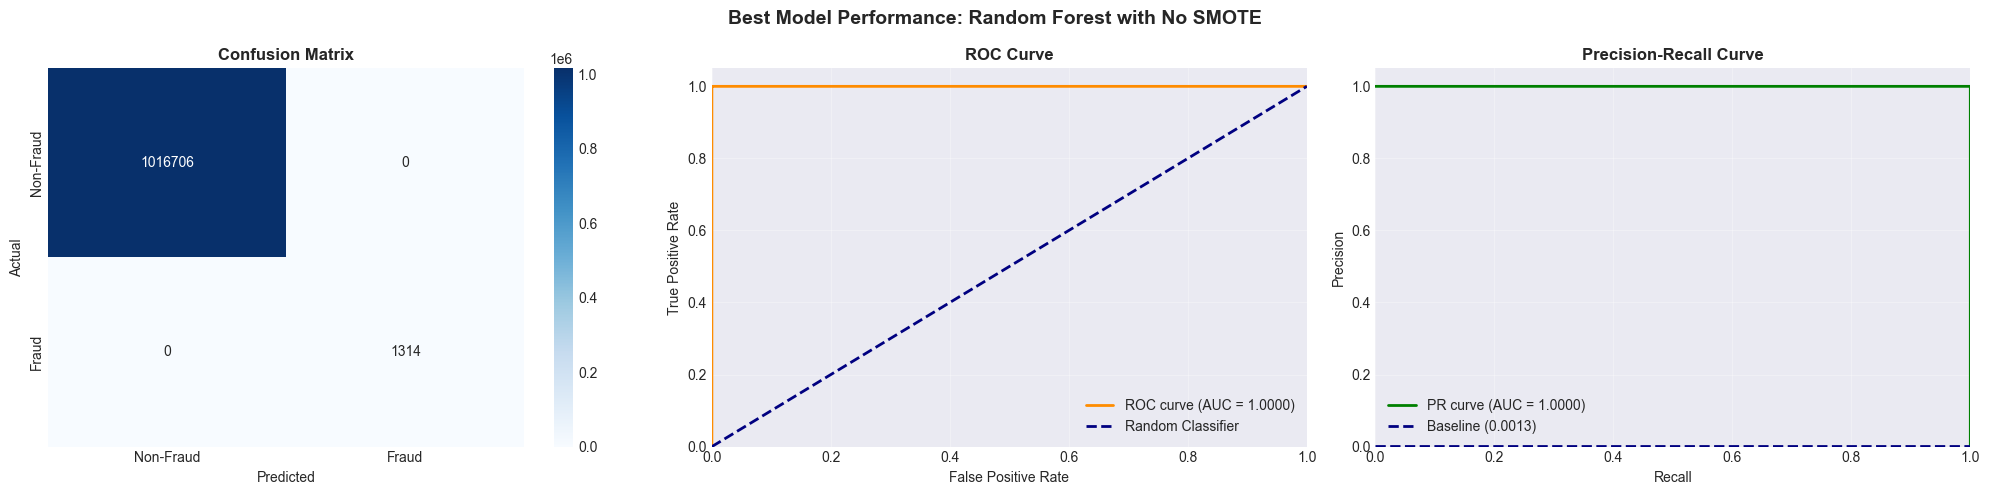

In [18]:
# Visualize confusion matrix and curves
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['Non-Fraud', 'Fraud'])
axes[0].set_yticklabels(['Non-Fraud', 'Fraud'])

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# Precision-Recall Curve
precision_curve, recall_curve, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall_curve, precision_curve)
axes[2].plot(recall_curve, precision_curve, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
axes[2].axhline(y=y_val.mean(), color='navy', linestyle='--', lw=2, label=f'Baseline ({y_val.mean():.4f})')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[2].legend(loc='lower left')
axes[2].grid(alpha=0.3)

plt.suptitle(f'Best Model Performance: {best_result["Model"]} with {best_result["SMOTE"]}', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Feature Importance (for tree-based models)

Analyze which features are most important for the best model.


Top 20 Most Important Features:
                 feature  importance
fraudRatioAmongReceivers    0.303196
  fraudRatioAmongSenders    0.261751
   isBalanceAnnihilation    0.085271
           oldbalanceOrg    0.071882
          newbalanceOrig    0.042292
                meanSent    0.032871
            type_encoded    0.032862
               totalSent    0.024909
                  amount    0.024789
   fraction_PAYMENT_recv    0.016107
         avgAmountToDest    0.014751
        fraction_PAYMENT    0.013751
                    step    0.010293
  fraction_TRANSFER_recv    0.009928
                     day    0.008835
          oldbalanceDest    0.008258
       fraction_TRANSFER    0.008039
           totalReceived    0.006237
          newbalanceDest    0.005637
        fraction_CASH_IN    0.005505


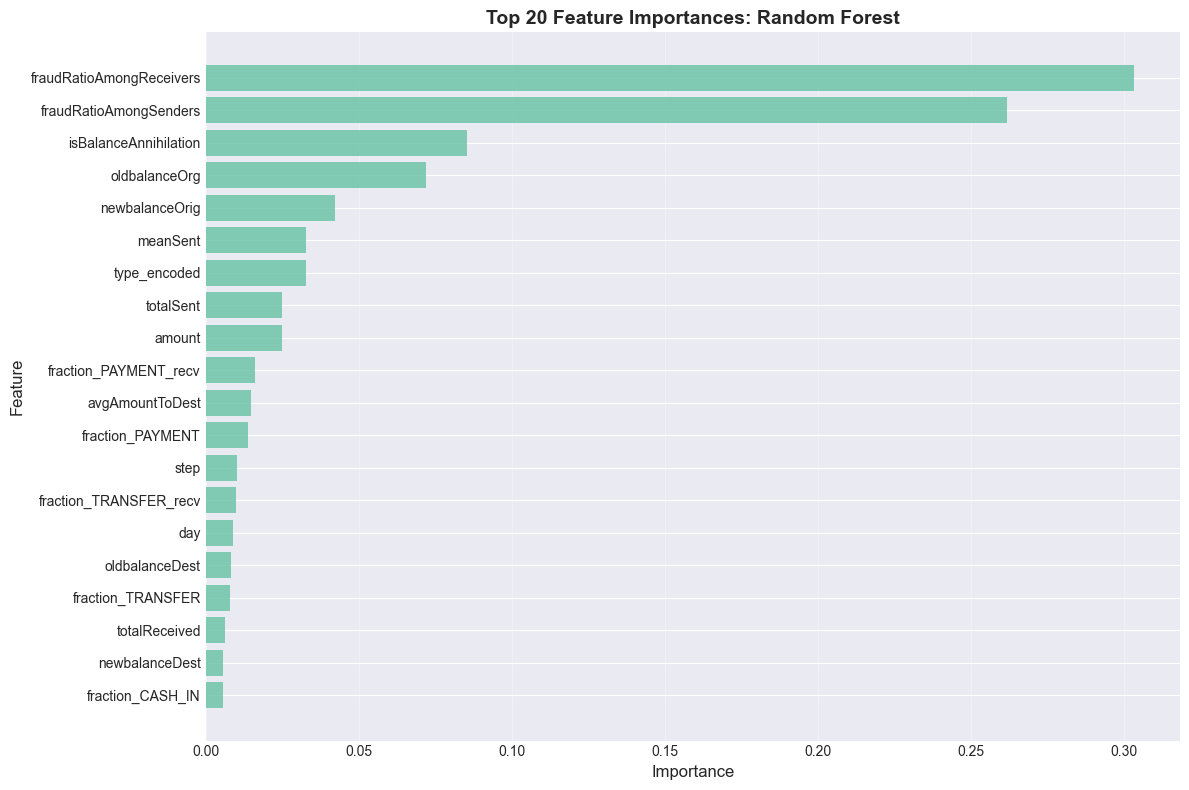

In [19]:
# Feature importance (only for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\nTop 20 Most Important Features:")
    print(feature_importance.head(20).to_string(index=False))
    
    # Plot top 20 features
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(20)
    plt.barh(range(len(top_features)), top_features['importance'], alpha=0.8)
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.title(f'Top 20 Feature Importances: {best_result["Model"]}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    # For logistic regression
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'coefficient': best_model.coef_[0]
    })
    feature_importance['abs_coefficient'] = abs(feature_importance['coefficient'])
    feature_importance = feature_importance.sort_values('abs_coefficient', ascending=False)
    
    print("\nTop 20 Most Important Features (by absolute coefficient):")
    print(feature_importance.head(20).to_string(index=False))
    
    # Plot top 20 features
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(20)
    colors = ['red' if x < 0 else 'green' for x in top_features['coefficient']]
    plt.barh(range(len(top_features)), top_features['coefficient'], alpha=0.8, color=colors)
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Coefficient', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.title(f'Top 20 Feature Coefficients: {best_result["Model"]}\n(Green = positive, Red = negative)', 
              fontsize=14, fontweight='bold')
    plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\nFeature importance not available for this model type.")

## 11. Final Evaluation on Test Set

Evaluate the best model on the held-out test set.

In [20]:
# Final predictions on test set
y_test_pred = best_model.predict(X_test)
y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Calculate metrics
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)
test_pr_auc = average_precision_score(y_test, y_test_pred_proba)

print("\n" + "="*80)
print("FINAL TEST SET RESULTS")
print("="*80)
print(f"Model: {best_result['Model']}")
print(f"SMOTE: {best_result['SMOTE']}")
print("\nTest Set Performance:")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")
print(f"  ROC-AUC: {test_roc_auc:.4f}")
print(f"  PR-AUC: {test_pr_auc:.4f}")

print("\nValidation Set Performance (for comparison):")
print(f"  Precision: {best_result['Precision']:.4f}")
print(f"  Recall: {best_result['Recall']:.4f}")
print(f"  F1-Score: {best_result['F1-Score']:.4f}")
print(f"  ROC-AUC: {best_result['ROC-AUC']:.4f}")
print(f"  PR-AUC: {best_result['PR-AUC']:.4f}")

# Classification report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=['Non-Fraud', 'Fraud']))

# Confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix (Test Set):")
print(cm_test)
print(f"\nTrue Negatives: {cm_test[0,0]:,}")
print(f"False Positives: {cm_test[0,1]:,}")
print(f"False Negatives: {cm_test[1,0]:,}")
print(f"True Positives: {cm_test[1,1]:,}")


FINAL TEST SET RESULTS
Model: Random Forest
SMOTE: No SMOTE

Test Set Performance:
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  ROC-AUC: 1.0000
  PR-AUC: 1.0000

Validation Set Performance (for comparison):
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  ROC-AUC: 1.0000
  PR-AUC: 1.0000

Classification Report (Test Set):
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00   1270881
       Fraud       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524


Confusion Matrix (Test Set):
[[1270881       0]
 [      0    1643]]

True Negatives: 1,270,881
False Positives: 0
False Negatives: 0
True Positives: 1,643


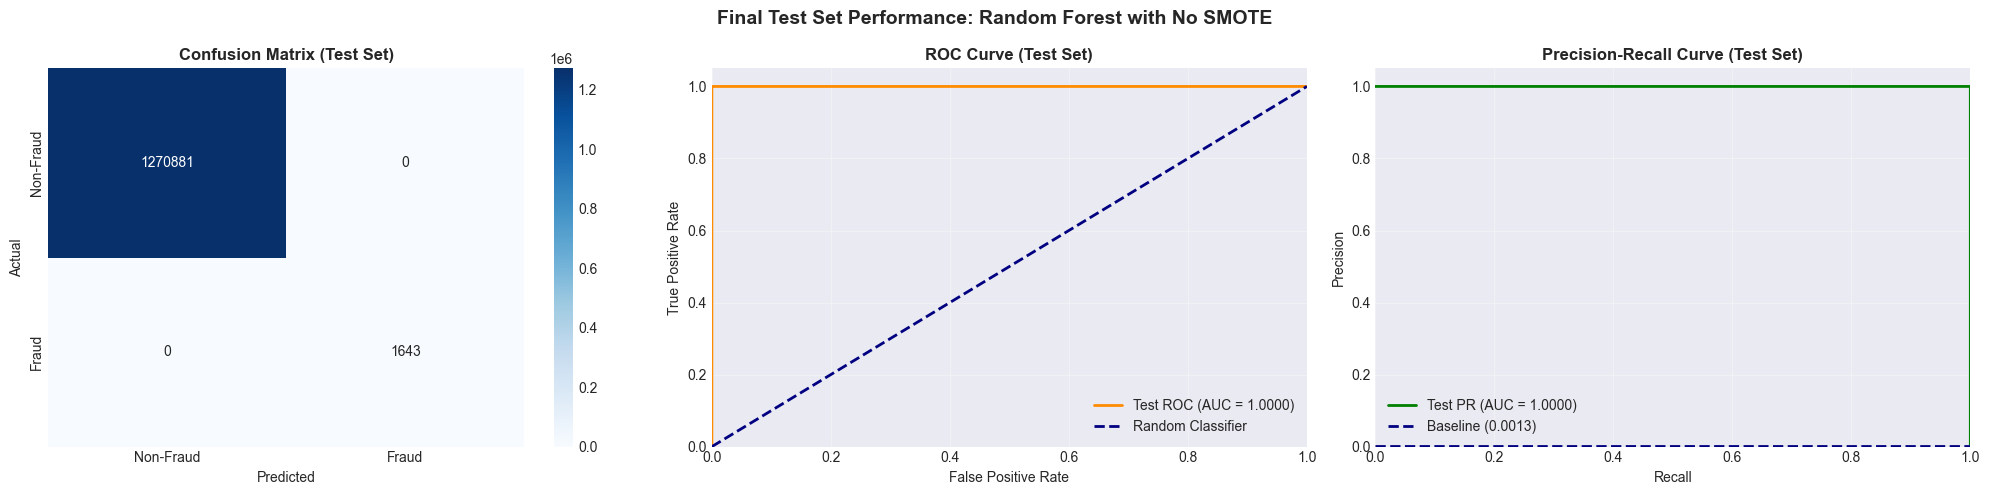

In [21]:
# Visualize test set results
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Confusion Matrix
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['Non-Fraud', 'Fraud'])
axes[0].set_yticklabels(['Non-Fraud', 'Fraud'])

# ROC Curve
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_proba)
roc_auc_test = auc(fpr_test, tpr_test)
axes[1].plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'Test ROC (AUC = {roc_auc_test:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Test Set)', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# Precision-Recall Curve
precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_pred_proba)
pr_auc_test = auc(recall_test, precision_test)
axes[2].plot(recall_test, precision_test, color='green', lw=2, label=f'Test PR (AUC = {pr_auc_test:.4f})')
axes[2].axhline(y=y_test.mean(), color='navy', linestyle='--', lw=2, label=f'Baseline ({y_test.mean():.4f})')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve (Test Set)', fontsize=12, fontweight='bold')
axes[2].legend(loc='lower left')
axes[2].grid(alpha=0.3)

plt.suptitle(f'Final Test Set Performance: {best_result["Model"]} with {best_result["SMOTE"]}', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Summary and Insights

Key findings and recommendations.

In [22]:
# Create summary comparison
print("\n" + "="*80)
print("EXPERIMENT SUMMARY")
print("="*80)

print(f"\nTotal combinations tested: {len(results)}")
print(f"SMOTE strategies: {len(smote_strategies)}")
print(f"Models: {len(models)}")

print(f"\nBest combination (by validation F1-Score):")
print(f"  Model: {best_result['Model']}")
print(f"  SMOTE: {best_result['SMOTE']}")
print(f"  Validation F1: {best_result['F1-Score']:.4f}")
print(f"  Test F1: {test_f1:.4f}")

# Compare with baseline (No SMOTE)
print(f"\nComparison with baseline (No SMOTE):")
for model_name in models.keys():
    baseline = results_df[(results_df['Model'] == model_name) & (results_df['SMOTE'] == 'No SMOTE')]
    best_smote = results_df[(results_df['Model'] == model_name) & (results_df['SMOTE'] != 'No SMOTE')].sort_values('F1-Score', ascending=False).iloc[0]
    
    if not baseline.empty:
        improvement = ((best_smote['F1-Score'] - baseline['F1-Score'].values[0]) / baseline['F1-Score'].values[0]) * 100
        print(f"\n  {model_name}:")
        print(f"    Baseline F1: {baseline['F1-Score'].values[0]:.4f}")
        print(f"    Best SMOTE ({best_smote['SMOTE']}) F1: {best_smote['F1-Score']:.4f}")
        print(f"    Improvement: {improvement:+.2f}%")

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)
print("""\n1. SMOTE Impact: Compare 'No SMOTE' baseline with SMOTE variants to assess value
2. Model Performance: Identify which model architecture works best for fraud detection
3. SMOTE-Model Interaction: Different models may benefit from different SMOTE strategies
4. Validation vs Test: Check for overfitting by comparing validation and test metrics
5. Precision-Recall Trade-off: Consider business costs of false positives vs false negatives

Recommendations:
- Use validation results to tune models and select SMOTE strategy
- Consider ensemble methods combining multiple top models
- Adjust classification threshold based on business requirements
- Monitor model performance over time as fraud patterns evolve
""")


EXPERIMENT SUMMARY

Total combinations tested: 12
SMOTE strategies: 4
Models: 3

Best combination (by validation F1-Score):
  Model: Random Forest
  SMOTE: No SMOTE
  Validation F1: 1.0000
  Test F1: 1.0000

Comparison with baseline (No SMOTE):

  Logistic Regression:
    Baseline F1: 0.0555
    Best SMOTE (Borderline-SMOTE) F1: 0.0651
    Improvement: +17.28%

  Random Forest:
    Baseline F1: 1.0000
    Best SMOTE (Standard SMOTE) F1: 1.0000
    Improvement: +0.00%

  XGBoost:
    Baseline F1: 1.0000
    Best SMOTE (Standard SMOTE) F1: 0.9992
    Improvement: -0.08%

KEY INSIGHTS

1. SMOTE Impact: Compare 'No SMOTE' baseline with SMOTE variants to assess value
2. Model Performance: Identify which model architecture works best for fraud detection
3. SMOTE-Model Interaction: Different models may benefit from different SMOTE strategies
4. Validation vs Test: Check for overfitting by comparing validation and test metrics
5. Precision-Recall Trade-off: Consider business costs of false po

## 13. Save Best Model (Optional)

Save the best performing model for deployment.

In [23]:
import pickle

# Save best model
model_filename = f'../models/best_fraud_model_{best_result["Model"].replace(" ", "_")}_{best_result["SMOTE"].replace(" ", "_")}.pkl'

# Create models directory if it doesn't exist
import os
os.makedirs('../models', exist_ok=True)

with open(model_filename, 'wb') as f:
    pickle.dump(best_model, f)

print(f"Best model saved to: {model_filename}")

# Save results summary
results_df.to_csv('../models/validation_results_summary.csv', index=False)
print("Results summary saved to: ../models/validation_results_summary.csv")

Best model saved to: ../models/best_fraud_model_Random_Forest_No_SMOTE.pkl
Results summary saved to: ../models/validation_results_summary.csv
